In [40]:
import os
import pandas as pd
import h5py as h5
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib to use IEEE-style fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

In [41]:
from pyparsing import line


def plot_f1_scores(csv_path, title, architectures=None, save_path=None, ax=None, lc=False):
    """
    Read a CSV file and plot F1-score trajectories with uncertainty bands.

    Args:
        csv_path (str): Path to the CSV file.
        title (str): Title for the plot.
        architectures (Iterable[str] | None): Optional iterable of architecture names
            (e.g. {"ATAT", "DiT", "DiViT-L"}) to include in the plot.
        save_path (str | None): Optional path to save the generated figure. When None the plot is not saved.
        ax (matplotlib.axes.Axes | None): Existing axes to plot on. If None, creates new figure.
        lc (bool): Whether this is the LC plot (shows y-axis labels).
    """
    data = pd.read_csv(csv_path)
    mean_df = pd.concat([data.iloc[:, [0]], data.iloc[:, 1::2]], axis=1)
    std_df = pd.concat([data.iloc[:, [0]], data.iloc[:, 2::2]], axis=1)
    mean_df.columns = [col.replace('_mean', '') for col in mean_df.columns]
    std_df.columns = [col.replace('_std', '') for col in std_df.columns]

    raw_names = mean_df['experiment_name'].astype(str)
    simclr_mask = ~raw_names.str.contains('simclr', case=False, na=False)
    windows_mask = ~raw_names.str.contains('windows', case=False, na=False)
    valid_mask = simclr_mask & windows_mask
    mean_df = mean_df.loc[valid_mask].reset_index(drop=True)
    std_df = std_df.loc[valid_mask].reset_index(drop=True)

    # Normalize experiment naming conventions
    def clean_name(name: str) -> str:
        if not isinstance(name, str):
            return name
        cleaned = name.replace('MM', '')
        cleaned = cleaned.replace('LCMD', '')
        cleaned = cleaned.replace('LC_MD', '')
        cleaned = cleaned.replace('DiViT_L', 'DiViT-L')
        cleaned = cleaned.replace('VICReg', 'Pretrained')
        cleaned = cleaned.replace('_', '')
        cleaned = cleaned.replace('DiViTL', 'DiViT-L')
        cleaned = cleaned.replace('DiT', 'DiffT')
        cleaned = cleaned.replace('DiViT','DiffViT')
        cleaned = cleaned.replace('-PT', 'Pretrained')
        
        return cleaned.strip()
    mean_df['experiment_name'] = mean_df['experiment_name'].map(clean_name)
    std_df['experiment_name'] = std_df['experiment_name'].map(clean_name)

    def architecture_key(label: str) -> str:
        if not isinstance(label, str):
            return label
        base = label.replace('Pretrained', '').strip()
        return base.split()[0] if base else base

    # Filter architectures when requested
    if architectures:
        selected = {arch.strip().lower() for arch in architectures}
        arch_mask = mean_df['experiment_name'].apply(
            lambda name: architecture_key(name).lower() in selected if isinstance(name, str) else False
        )
        mean_df = mean_df.loc[arch_mask].reset_index(drop=True)
        std_df = std_df.loc[arch_mask].reset_index(drop=True)

    if mean_df.empty:
        raise ValueError("No experiments remain after filtering; please adjust the selected architectures or input data.")

    metric_cols = mean_df.columns[1:]  # exclude 'experiment_name'

    def extract_numeric(label):
        numbers = ''.join(ch if ch.isdigit() or ch == '.' else ' ' for ch in label).split()
        return float(numbers[-1]) if numbers else float('inf')
    sorted_indices = sorted(range(len(metric_cols)), key=lambda i: extract_numeric(metric_cols[i]))
    ordered_metrics = [metric_cols[i] for i in sorted_indices]
    ordered_ticks = [extract_numeric(metric) for metric in ordered_metrics]
    x_positions = np.arange(len(ordered_metrics), dtype=float)

    # Define custom color scheme: green, black, blue, purple
    colors = ['#2ca02c', '#000000', '#1f77b4', '#9467bd']
    experiment_colors = {name: colors[idx % len(colors)] for idx, name in enumerate(mean_df['experiment_name'])}

    # Create figure if ax not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    else:
        fig = ax.get_figure()
    line_styles = ['-', '--', '-.', 'dotted']
    for idx, row in mean_df.iterrows():
        experiment_name = row['experiment_name']
        lowercase_name = experiment_name.lower()
        is_pt = experiment_name.endswith('Pretrained') or 'pretrained' in lowercase_name
        y = row[ordered_metrics].astype(float).values
        color = experiment_colors[experiment_name]
        linestyle = line_styles[idx % len(line_styles)]
        
        # Plot line
        ax.plot(
            x_positions, y, label=experiment_name, color=color, linestyle=linestyle,
            linewidth=2, markersize=10, alpha=0.9
        )
        
        # Add error bands
        std_row = std_df.loc[std_df['experiment_name'] == experiment_name]
        if not std_row.empty:
            std_values = std_row.iloc[0][ordered_metrics].astype(float).values
            ax.fill_between(
                x_positions, 
                y - std_values, 
                y + std_values, 
                color=color, 
                alpha=0.2
            )
    
    ax.set_xlim(-0.5, len(ordered_metrics) - 0.5)
    ax.set_ylim(0.3, 0.91)
    #ax.set_title(title, fontsize=20, fontweight='bold', color='#1A1A1A', pad=5)
    ax.set_xlabel('Days after first alert', fontsize=20, color="#000000")
    
    # Show y-axis labels only for first plot (lc=True)
    if lc:
        ax.set_ylabel('F1 Score', fontsize=20, color="#000000")
        ax.tick_params(axis='y', labelsize=14, colors='#000000', length=10, width=2)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', labelsize=20, colors='#2C3E50', length=10, width=2)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"{tick:.0f}" for tick in ordered_ticks], fontsize=14, color="#000000")
    ax.tick_params(axis='x', labelsize=14)
    ax.set_facecolor("#FFFFFF")
    ax.margins(x=0.02, y=0.08)

    legend = ax.legend(fontsize=20, loc='lower right', frameon=True, framealpha=0.92,
                       fancybox=True, shadow=False, borderpad=0.8, labelspacing=0.6)
    for text in legend.get_texts():
        text.set_color("#000000")

    for spine in ax.spines.values():
        spine.set_color("#000000")
        spine.set_linewidth(0.5)

    return fig, ax

In [42]:
output_dir = '../logs/plot_exports'
os.makedirs(output_dir, exist_ok=True)

In [43]:
architectures = ['ATAT','DiffViT-L','DiffT']

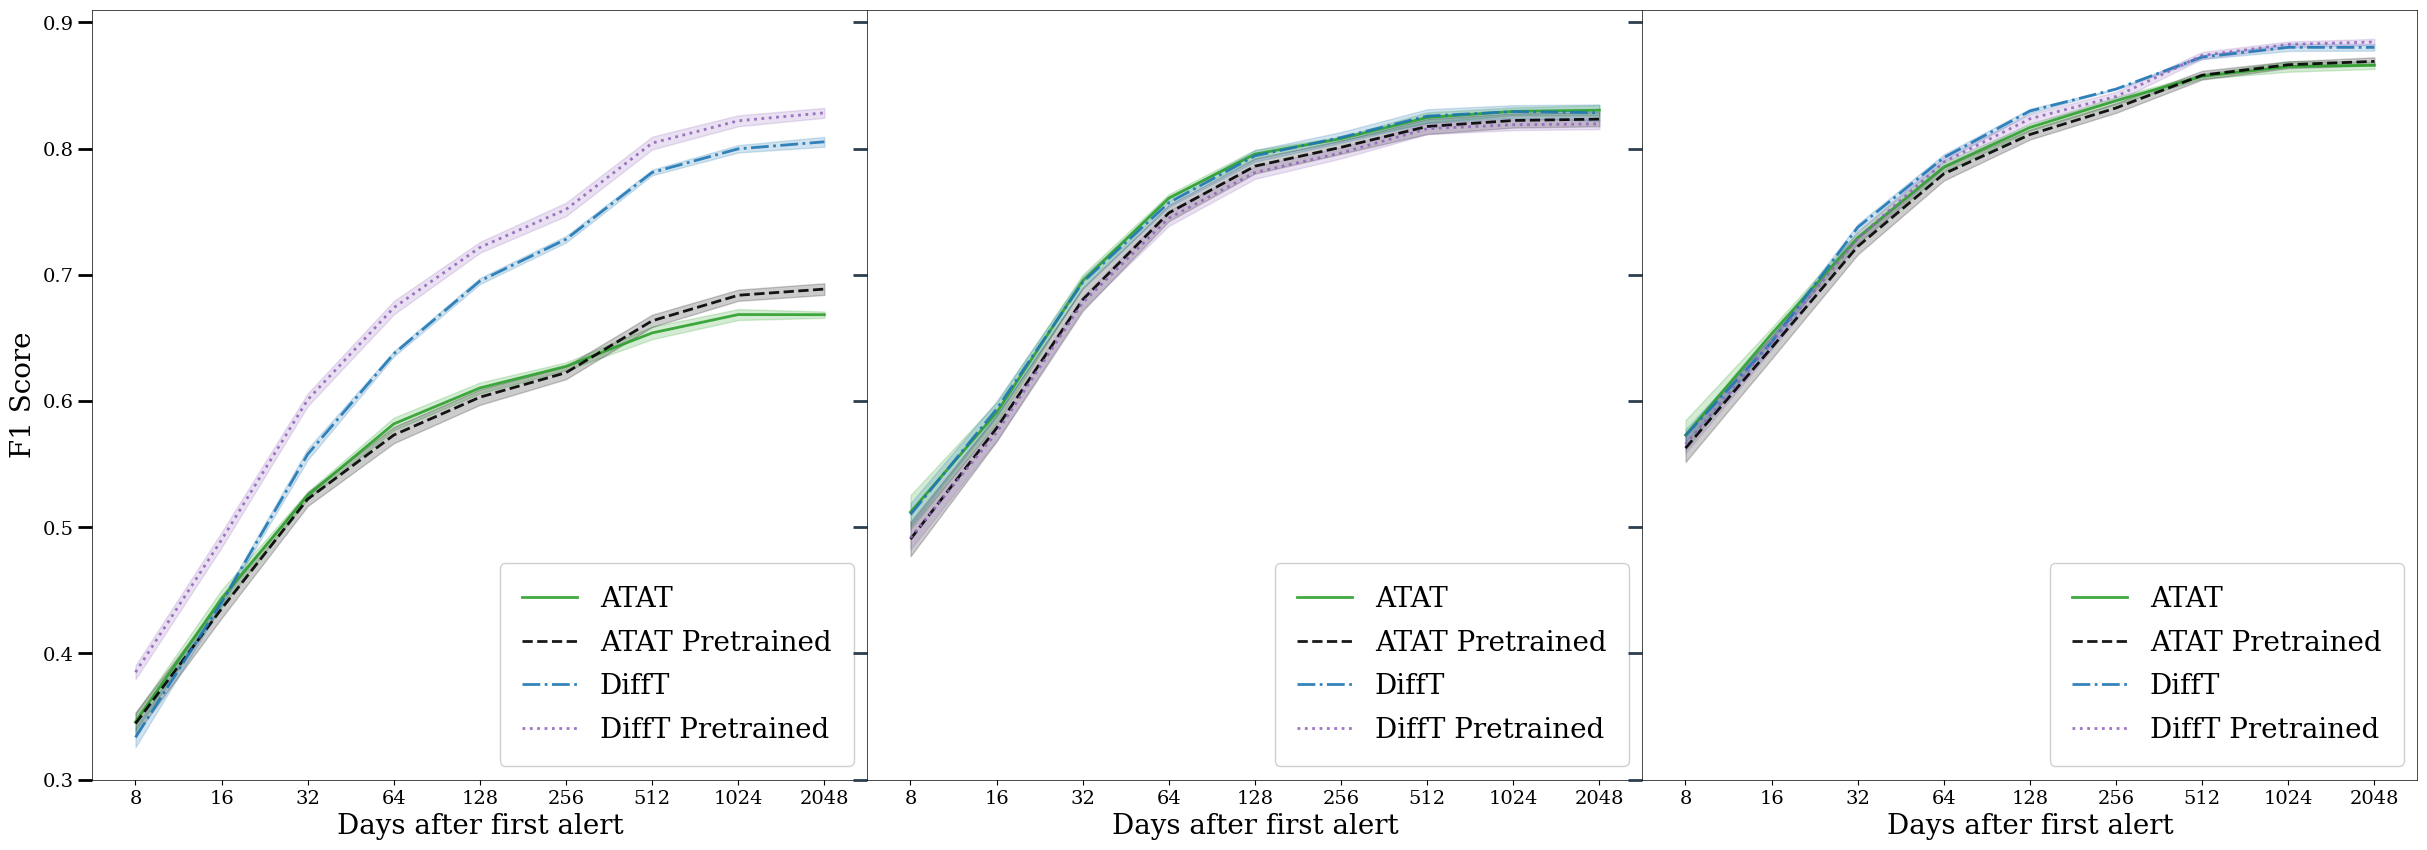

In [44]:
# Create side-by-side plots for all three modalities
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

# LC plot
path_lcmd_lc = '/home/fsoto/Documents/SSLPeriodicLCs/logs/eval/ATATPeriodicComparisonTTE_multimodal_LC.csv'
title_lcmd_lc = 'LC-MTA'
plot_f1_scores(
    csv_path=path_lcmd_lc,
    title=title_lcmd_lc,
    architectures={'ATAT','DiffViT-L','DiffT'},
    ax=axes[0],
    lc=True
)

# Feat plot
path_lcmd_feat = '/home/fsoto/Documents/SSLPeriodicLCs/logs/eval/ATATPeriodicComparisonTTE_multimodal_Feat.csv'
title_lcmd_feat = 'MD-FT'
plot_f1_scores(
    csv_path=path_lcmd_feat,
    title=title_lcmd_feat,
    architectures={'ATAT','DiffViT-L','DiffT'},
    ax=axes[1],
    lc=False
)

# Mix plot
path_lcmd_mix = '/home/fsoto/Documents/SSLPeriodicLCs/logs/eval/ATATPeriodicComparisonTTE_multimodal_Mix.csv'
title_lcmd_mix = 'LC-MD-MTA'
plot_f1_scores(
    csv_path=path_lcmd_mix,
    title=title_lcmd_mix,
    architectures={'ATAT','DiffViT-L','DiffT'},
    ax=axes[2],
    lc=False
)

plt.subplots_adjust(wspace=0)
fig.savefig(os.path.join(output_dir, 'ATATPeriodicComparisonTTE_multimodal_combined.pdf'), dpi=1200, bbox_inches='tight')
plt.show()